### Many to One with Seq2Seq model

In [156]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import time
import numpy as np
from tqdm import tqdm
from IPython.core.debugger import Pdb
import torch
import torch.nn as nn
import torch.nn.functional as F
from utils.utils import time_since, plot, plots
from utils.mora import Mora
#from datasets.itemdataset import ItemDataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Encoder

In [157]:
n_class = 2200
vocab_size = len(Mora) + 1  # 0: Start of sequence
hidden_size = 256
target_size = 1
batch_size = 1

In [158]:
input_sequence = torch.LongTensor([23, 1, 21, 32, 43, 1, 101, 34])
target = torch.LongTensor([120])   # correct label

In [159]:
embedding = nn.Embedding(vocab_size, hidden_size)
embed_seq = embedding(input_sequence)

In [160]:
embed_seq.shape

torch.Size([8, 256])

In [161]:
gru = nn.GRU(hidden_size, hidden_size, num_layers=1, bidirectional=False)

In [162]:
h0 = torch.zeros(1, 1, hidden_size)
out, h_enc = gru(embed_seq.view(embed_seq.shape[0], batch_size, -1), h0)  # (T(timestep), N(batch size), H(feature))

In [163]:
out.shape

torch.Size([8, 1, 256])

In [164]:
h_enc.shape

torch.Size([1, 1, 256])

Decoder

In [165]:
target.shape

torch.Size([1])

In [166]:
embedding2 = nn.Embedding(n_class, hidden_size)
emb2 = embedding2(target)

In [167]:
emb2.shape

torch.Size([1, 256])

In [168]:
relu = nn.ReLU()
emb2 = relu(emb2)

In [169]:
gru2 = nn.GRU(hidden_size, hidden_size)
dec_out, dec_h = gru2(emb2.view(emb2.shape[0], batch_size, -1), h_enc)  # init hidden with encoder's

In [170]:
dec_out.shape

torch.Size([1, 1, 256])

In [171]:
fc = nn.Linear(hidden_size, n_class)
dec_out = fc(dec_out)
dec_out.shape

torch.Size([1, 1, 2200])

In [172]:
softmax = nn.LogSoftmax(dim=1)

In [173]:
dec_out = softmax(dec_out)
dec_out

tensor([[[0., 0., 0.,  ..., 0., 0., 0.]]], grad_fn=<LogSoftmaxBackward>)

Calculate Loss

In [174]:
criterion = nn.CrossEntropyLoss()

In [175]:
dec_out.view(batch_size, -1).shape

torch.Size([1, 2200])

In [176]:
loss = criterion(dec_out.view(batch_size, -1), target)

In [177]:
target = torch.autograd.Variable(torch.LongTensor(batch_size).random_(0, 2000-1))

In [178]:
loss.item()

7.6962127685546875

In [179]:
loss.backward()

In [180]:
# predict
dist = torch.distributions.Categorical(dec_out.view(-1).exp())
dist.sample()

tensor(1815)

Models

In [181]:
class Encoder(nn.Module):
    def __init__(self, n_class, vocab_size, hidden_size, target_size, batch_size):
        super(Encoder, self).__init__()
        self.n_class = n_class
        self.vocab_size = vocab_size
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.target_size = target_size
        
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers=1, bidirectional=False)
        
    def forward(self, input_sequence, hidden):
        #import pdb; pdb.set_trace()
        embed_seq = self.embedding(input_sequence).view(1, self.batch_size, -1)
        out, h = self.gru(embed_seq, hidden)
        return out, h

In [182]:
class Decoder(nn.Module):
    def __init__(self, n_class, vocab_size, hidden_size, target_size, batch_size):
        super(Decoder, self).__init__()
        self.n_class = n_class
        self.vocab_size = vocab_size
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.target_size = target_size
        
        self.embedding = nn.Embedding(n_class, hidden_size)
        self.relu = nn.ReLU()
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers=1, bidirectional=False)
        self.fc = nn.Linear(hidden_size, n_class)
        
    def forward(self, input_sequence, hidden):
        #import pdb; pdb.set_trace()
        input_sequence = self.embedding(input_sequence)  # input_sequence shape is (1,)
        input_sequence = self.relu(input_sequence)
        out, h = self.gru(input_sequence.view(input_sequence.shape[0], self.batch_size, -1), hidden)  # hidden from encoder
        out = self.fc(out[0])
        out = out.view(self.batch_size, -1)  # (N, H)
        return out, h

In [183]:
class Seq2Class(nn.Module):
    def __init__(self, n_class, vocab_size, hidden_size, target_size, batch_size):
        super(Seq2Class, self).__init__()
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.n_class = n_class
        self.target_size = target_size
        self.encoder = Encoder(n_class, vocab_size, hidden_size, target_size, batch_size) 
        self.decoder = Decoder(n_class, vocab_size, hidden_size, target_size, batch_size)
        self.softmax = nn.LogSoftmax(dim=1)
        
    def init_hidden(self):
        return torch.zeros(self.batch_size, 1, self.hidden_size)
        
    def forward(self, input_sequence):
        h = self.init_hidden()
        for mora in input_sequence:
            encoder_out, h = self.encoder(mora, h)
        decoder_out, h = self.decoder(input_sequence, h)
        return decoder_out
        
    def infer(self, input_sequence):
        #import pdb; pdb.set_trace()
        h = self.init_hidden()
        for c in input_sequence:
            out, h = self.encoder(c, h)
        out, h = self.decoder(input_sequence, h)
        out = self.softmax(out).view(self.batch_size, -1)
        return out  # softmax distribution

Train Test

In [184]:
def check_data(step):
    if step % 3 == 0:
        x = torch.LongTensor([1,1,2,2])
        y = torch.LongTensor([11])
    if step % 3 == 1:
        x = torch.LongTensor([1,2,2,1])
        y = torch.LongTensor([33])
    if step % 3 == 2:
        x = torch.LongTensor([2,2,1,1])
        y = torch.LongTensor([22]) 
    return x, y

In [185]:
def train(n_epoch=2, n_steps=100, batch_size=1, lr=0.0001):
    
    n_class = 2300  # len of Animal
    vocab_size = len(Mora) + 1  # 0: SOS token
    hidden_size = 256
    target_size = 1
    batch_size = 1
    
    model = Seq2Class(n_class, vocab_size, hidden_size, target_size, batch_size)
    model.train()
    optimizer = torch.optim.Adam(model.parameters())
    for p in optimizer.param_groups:
        p['lr'] = lr
        
    criterion = nn.CrossEntropyLoss()#.cuda()
    start = time.time()
    running_loss = 0
    losses = []
    loss_aves = []
    total_iter = 0
    for epoch in range(n_epoch):
        for step in tqdm(range(n_steps)):  # <- replace with DataLoader instance here
            
            seq_len = torch.LongTensor(1).random_(1, 30)
            x = torch.LongTensor(seq_len)
            y = torch.LongTensor(1).random_(1, n_class)
            
            x, y = check_data(step)  # NOTE: use only test
                
            optimizer.zero_grad()
 
            x = x#.cuda()
            y = y#.cuda()

            dist = model.forward(x)
            
            loss = criterion(dist, y)
            running_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
          
            speed = (step + 1) / (time.time() - start)
            t = time_since(start)
            loss_ave = running_loss / (total_iter + 1)
            
            if step % 10 == 0:
                print(f'input:{x.numpy()} label:{y.numpy()} predict:{np.argmax(model.infer(x).detach().numpy())}')
                print(f'epoch {epoch} -- step: {step}/{n_steps} -- loss ave: {loss_ave:.4f} -- loss: {loss.item():.4f} -- t: {t} -- speed: {speed:.1f} steps/sec')
                
            losses += [loss.item()]
            loss_aves += [loss_ave]
            
            total_iter += 1
            
    return losses, loss_aves, model

In [186]:
losses, loss_aves, model = train()

 11%|█         | 11/100 [00:00<00:01, 45.27it/s]

input:[1 1 2 2] label:[11] predict:2017
epoch 0 -- step: 0/100 -- loss ave: 8.0768 -- loss: 8.0768 -- t: 0m 0s -- speed: 27.2 steps/sec
input:[1 2 2 1] label:[33] predict:33
epoch 0 -- step: 10/100 -- loss ave: 7.6300 -- loss: 7.1674 -- t: 0m 0s -- speed: 47.8 steps/sec


 27%|██▋       | 27/100 [00:00<00:01, 48.34it/s]

input:[2 2 1 1] label:[22] predict:33
epoch 0 -- step: 20/100 -- loss ave: 7.3231 -- loss: 6.8272 -- t: 0m 0s -- speed: 48.1 steps/sec
input:[1 1 2 2] label:[11] predict:11
epoch 0 -- step: 30/100 -- loss ave: 6.9962 -- loss: 5.9904 -- t: 0m 0s -- speed: 49.2 steps/sec


 51%|█████     | 51/100 [00:01<00:00, 50.54it/s]

...

 69%|██████▉   | 69/100 [00:01<00:00, 51.35it/s]

input:[1 1 2 2] label:[11] predict:11
epoch 1 -- step: 60/100 -- loss ave: 2.9531 -- loss: 0.2088 -- t: 0m 3s -- speed: 19.2 steps/sec
input:[1 2 2 1] label:[33] predict:33
epoch 1 -- step: 70/100 -- loss ave: 2.7925 -- loss: 0.1932 -- t: 0m 3s -- speed: 21.1 steps/sec


 87%|████████▋ | 87/100 [00:01<00:00, 51.73it/s]

input:[2 2 1 1] label:[22] predict:22
epoch 1 -- step: 80/100 -- loss ave: 2.6481 -- loss: 0.1778 -- t: 0m 3s -- speed: 22.8 steps/sec
input:[1 1 2 2] label:[11] predict:11
epoch 1 -- step: 90/100 -- loss ave: 2.5176 -- loss: 0.1377 -- t: 0m 3s -- speed: 24.3 steps/sec


100%|██████████| 100/100 [00:01<00:00, 50.85it/s]


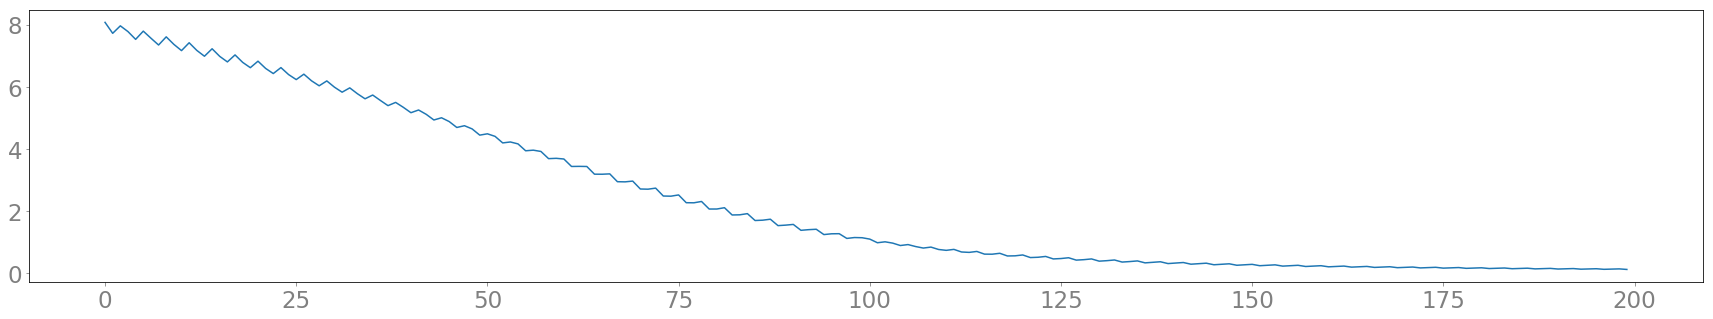

In [187]:
plot(losses)

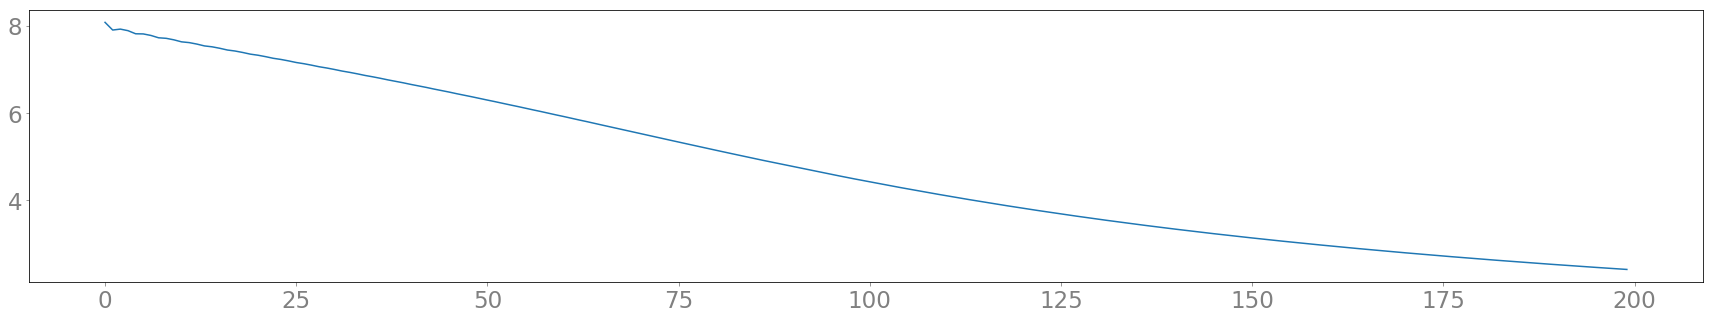

In [188]:
plot(loss_aves)